# 02. Mô hình baseline: TF-IDF và Logistic Regression

Notebook này xây dựng mốc hiệu năng ban đầu cho bài toán phân tích cảm xúc IMDb. Mô hình baseline dùng TF-IDF để biểu diễn văn bản và Logistic Regression để phân loại `negative` hoặc `positive`.

Kết quả thật trên tập test là 90.87% accuracy, 90.86% F1 macro và AUC 0.9681. Đây là một baseline mạnh: mô hình đúng 4,506 trên 4,959 review, nhưng vẫn sai 453 mẫu và đặc biệt khó xử lý các trường hợp ngữ cảnh phức tạp, phủ định, hoặc review dài có cảm xúc pha trộn.


## 1. Tổng quan và giả thuyết

Mục tiêu của bước này là tạo một mốc so sánh đơn giản, nhanh và dễ giải thích.

Giả thuyết ban đầu cho rằng TF-IDF kết hợp Logistic Regression có thể đạt mức cao trên IMDb vì nhiều từ cảm xúc rất trực tiếp. Kết quả xác nhận giả thuyết này: validation đạt 90.64% accuracy và test đạt 90.87% accuracy. Tuy nhiên, confusion matrix test có 264 False Positive và 189 False Negative, cho thấy baseline vẫn bị ảnh hưởng bởi từ khóa bề mặt thay vì hiểu toàn bộ ngữ cảnh.


## 2. Thiết lập môi trường

Ô mã dưới đây cấu hình đường dẫn dự án, nạp các module dùng chung, cố định seed và tạo các thư mục đầu ra. Việc gom cấu hình vào `src.config` giúp mọi notebook dùng cùng một tập hằng số.


In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.metrics import roc_curve

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from src import baseline, config, evaluate, visualize
from src.utils import Timer, ensure_dirs, set_seed

set_seed(config.SEED)
ensure_dirs()
print(f"Project root: {PROJECT_ROOT}")


Project root: /kaggle/working/imdb_sentiment_analysis


Sau khi chạy ô thiết lập, mọi đường dẫn tương đối sẽ được hiểu từ thư mục gốc của dự án. Điều này giúp notebook chạy ổn định cả khi mở từ thư mục `notebooks/` hoặc từ thư mục gốc.


## 3. Nạp dữ liệu

Dữ liệu đầu vào lấy trực tiếp từ `data/processed/`. Ba tập có tổng cộng 49,582 review: `train.csv` có 39,665 mẫu, `validation.csv` có 4,958 mẫu và `test.csv` có 4,959 mẫu. Các cột đúng theo pipeline gồm `clean_text`, `label` và `label_id`.

Phân phối nhãn gần cân bằng ở cả ba tập: train có 19,758 negative và 19,907 positive; validation có 2,470 negative và 2,488 positive; test có 2,470 negative và 2,489 positive. Vì vậy, accuracy, F1 macro và AUC đều có ý nghĩa khi đánh giá mô hình.


In [2]:
train_df = pd.read_csv(Path(config.DATA_DIR) / "train.csv")
val_df = pd.read_csv(Path(config.DATA_DIR) / "validation.csv")
test_df = pd.read_csv(Path(config.DATA_DIR) / "test.csv")

split_summary = pd.DataFrame(
    [
        {"split": "train", "rows": len(train_df)},
        {"split": "validation", "rows": len(val_df)},
        {"split": "test", "rows": len(test_df)},
    ]
)
label_distribution = pd.concat(
    {
        "train": train_df["label"].value_counts(normalize=True).sort_index(),
        "validation": val_df["label"].value_counts(normalize=True).sort_index(),
        "test": test_df["label"].value_counts(normalize=True).sort_index(),
    },
    axis=1,
).T

sample_reviews = train_df[["clean_text", "label", "label_id"]].sample(3, random_state=config.SEED)

display(split_summary)
display(label_distribution)
display(sample_reviews)


,split,rows
0,train,39665
1,validation,4958
2,test,4959


label,negative,positive
train,0.498122,0.501878
validation,0.498185,0.501815
test,0.498084,0.501916


,clean_text,label,label_id
27338,Two escaped convicts step out of the woods and...,negative,0
35635,"As an avid Disney fan, I was not totally impre...",negative,0
14206,"Like many others, I had been attracted to the ...",positive,1


Phần kiểm tra xác nhận kích thước dữ liệu và độ cân bằng nhãn đúng với artifact đã tạo. Tỷ lệ positive lần lượt là 50.19% ở train, 50.18% ở validation và 50.19% ở test; chênh lệch giữa hai lớp rất nhỏ nên không cần dùng class weighting cho baseline.


## 4.TF-IDF

### 4.1 TF-IDF

TF-IDF kết hợp hai thành phần: Term Frequency đo mức độ thường xuyên của một từ trong một văn bản, còn Inverse Document Frequency giảm trọng số của các từ xuất hiện trong quá nhiều văn bản. Vì vậy, một từ có trọng số cao khi nó xuất hiện đáng kể trong một review nhưng không quá phổ biến trong toàn bộ corpus.

Với `sublinear_tf=True`, số lần xuất hiện thô được thay bằng `1 + log(TF)`. Cách này tránh để một từ lặp lại quá nhiều lần chi phối toàn bộ vector.

### 4.2 Vì sao dùng bigram?

Cấu hình `ngram_range=(1, 2)` giữ cả unigram và bigram. Bigram như `not good`, `very bad` hoặc `waste time` giúp mô hình bắt được một phần phủ định và cụm cảm xúc ngắn mà unigram riêng lẻ dễ bỏ lỡ.

### 4.3 Kích thước vocabulary sau khi fit

Sau khi fit trên 39,665 review train, vectorizer giữ đúng 50,000 feature theo giới hạn `TFIDF_MAX_FEATURES=50000`. Các feature dương mạnh nhất gồm `great` hệ số 8.5133, `excellent` 6.8087 và `perfect` 5.5037. Các feature âm mạnh nhất gồm `bad` -8.9850, `worst` -8.7177 và `awful` -7.7371. Điều này xác nhận baseline học được tín hiệu cảm xúc rõ ràng, nhưng vẫn là bag-of-features nên không hiểu được quan hệ ngữ cảnh dài.


## 5. Huấn luyện baseline

Ô mã tiếp theo huấn luyện TF-IDF và Logistic Regression trên tập train, đánh giá nhanh trên validation, lưu artifacts vào `models/baseline/`, rồi hiển thị các feature có hệ số mạnh nhất.

Kết quả validation thật là 90.64% accuracy, 90.64% F1 macro, 90.68% precision macro, 90.64% recall macro và AUC 0.9685. Thời gian huấn luyện là 26.45 giây, phù hợp với vai trò baseline nhanh và nhẹ.


In [3]:
train_texts = train_df["clean_text"].astype(str).tolist()
train_labels = train_df["label_id"].astype(int).tolist()
val_texts = val_df["clean_text"].astype(str).tolist()
val_labels = val_df["label_id"].astype(int).tolist()
test_texts = test_df["clean_text"].astype(str).tolist()
test_labels = test_df["label_id"].astype(int).tolist()

with Timer() as timer:
    baseline_metrics = baseline.train_baseline(train_texts, train_labels, val_texts, val_labels)

validation_table = pd.DataFrame(
    [
        {"metric": "accuracy", "value": baseline_metrics["accuracy"]},
        {"metric": "f1_macro", "value": baseline_metrics["f1_macro"]},
        {"metric": "precision_macro", "value": baseline_metrics["precision_macro"]},
        {"metric": "recall_macro", "value": baseline_metrics["recall_macro"]},
        {"metric": "roc_auc", "value": baseline_metrics["roc_auc"]},
        {"metric": "training_time_seconds", "value": baseline_metrics["training_time_seconds"]},
        {"metric": "num_features", "value": baseline_metrics["num_features"]},
    ]
)
display(validation_table)

features = baseline.get_top_features(20)
display(pd.DataFrame(features["positive"], columns=["feature", "coefficient"]))
display(pd.DataFrame(features["negative"], columns=["feature", "coefficient"]))
print(f"Measured training timer: {timer}")


,metric,value
0,accuracy,0.906414
1,f1_macro,0.906386
2,precision_macro,0.906750
3,recall_macro,0.906363
4,roc_auc,0.968479
5,training_time_seconds,26.449648
6,num_features,50000.000000


,feature,coefficient
0,great,8.513269
1,excellent,6.808695
2,perfect,5.503724
3,wonderful,4.976520
4,amazing,4.933198
5,best,4.368913
6,the best,4.288780
7,loved,4.207281
8,fun,4.198675
9,brilliant,4.188462


,feature,coefficient
0,bad,-8.984954
1,worst,-8.717736
2,awful,-7.737073
3,boring,-7.010901
4,the worst,-6.932961
5,poor,-6.487497
6,terrible,-6.185390
7,waste,-6.036764
8,nothing,-5.448558
9,worse,-4.765325


Measured training timer: 27s


Các feature có hệ số dương lớn như `great`, `excellent`, `perfect`, `wonderful` và `amazing` phản ánh trực tiếp ngôn ngữ khen ngợi. Ngược lại, `bad`, `worst`, `awful`, `boring`, `poor` và `terrible` là các tín hiệu tiêu cực rất mạnh. Danh sách này hợp lý về mặt ngôn ngữ, nhưng cũng cho thấy hạn chế: nếu một review dùng từ tích cực trong ngữ cảnh phủ định hoặc mỉa mai, baseline dễ bị đánh lừa.


## 6. Đánh giá trên tập test

Sau validation, baseline được đánh giá trên tập test độc lập và lưu kết quả vào `results/metrics/baseline_results.json`. Hai hình tương ứng đã được lưu tại `results/figures/confusion_matrix_baseline.png` và `results/figures/roc_curve_baseline.png`.

,metric,value
0,accuracy,0.908651
1,f1_macro,0.908618
2,precision_macro,0.909061
3,recall_macro,0.908592
4,roc_auc,0.968102


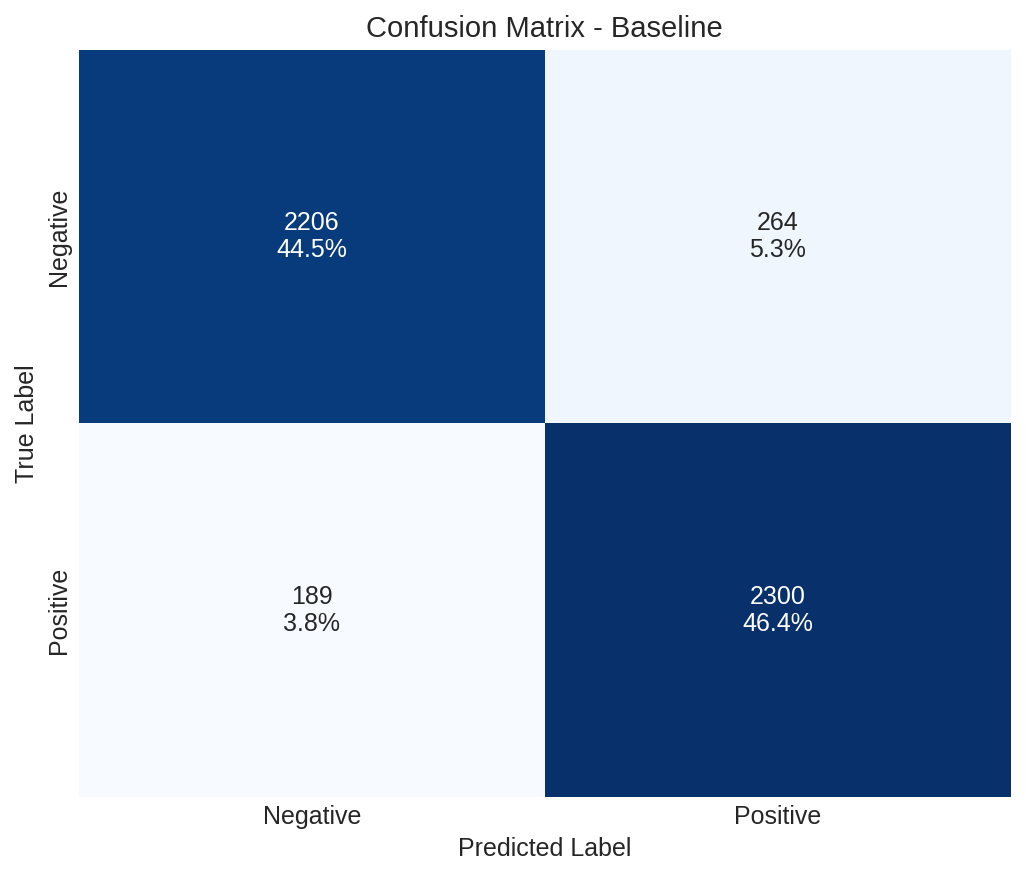

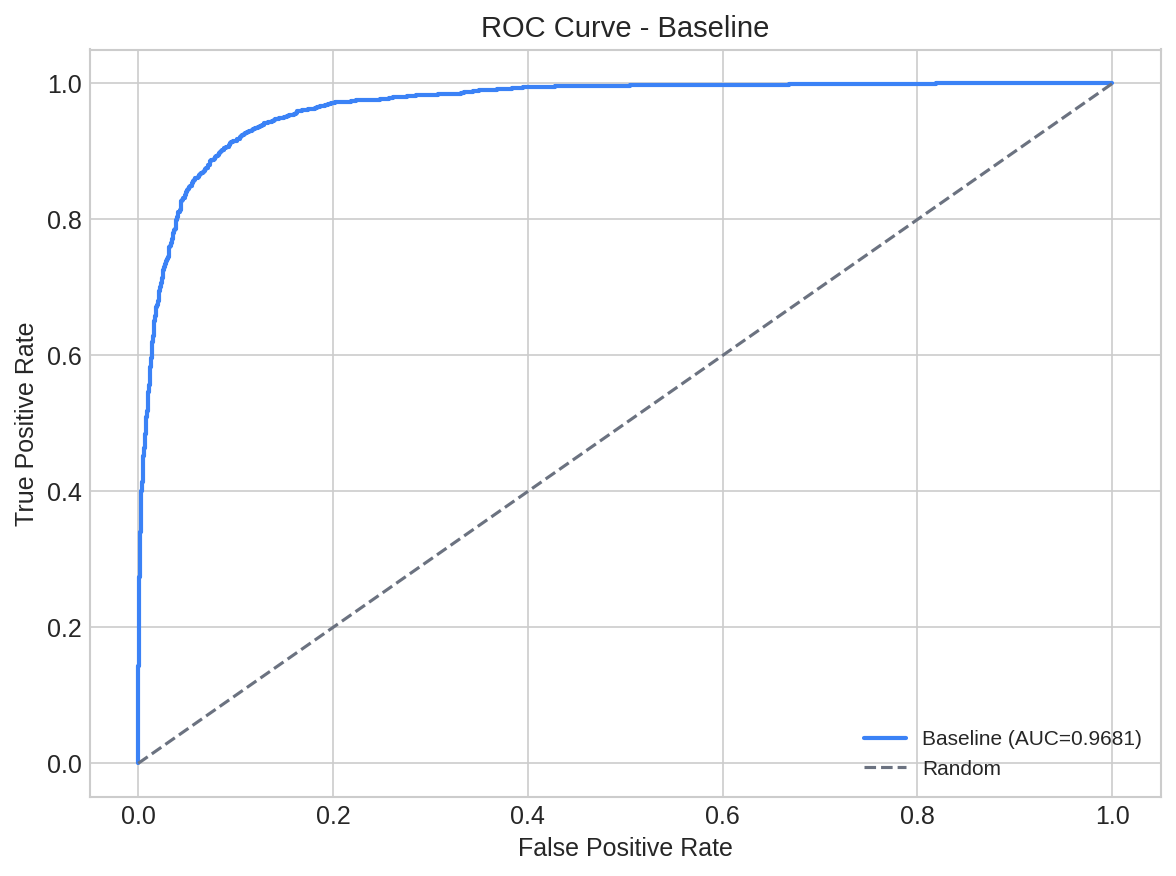

,precision,recall,f1-score,support
negative,0.921086,0.893117,0.906886,2470.000000
positive,0.897036,0.924066,0.910350,2489.000000
accuracy,0.908651,0.908651,0.908651,0.908651
macro avg,0.909061,0.908592,0.908618,4959.000000
weighted avg,0.909015,0.908651,0.908625,4959.000000


In [4]:
test_metrics = baseline.evaluate_baseline(test_texts, test_labels)

metrics_table = pd.DataFrame(
    [
        {"metric": "accuracy", "value": test_metrics["accuracy"]},
        {"metric": "f1_macro", "value": test_metrics["f1_macro"]},
        {"metric": "precision_macro", "value": test_metrics["precision_macro"]},
        {"metric": "recall_macro", "value": test_metrics["recall_macro"]},
        {"metric": "roc_auc", "value": test_metrics["roc_auc"]},
    ]
)
display(metrics_table)

confusion_path = str(Path(config.FIGURES_DIR) / "confusion_matrix_baseline.png")
visualize.plot_confusion_matrix(test_metrics["confusion_matrix"], "Baseline", confusion_path)
display(Image(filename=confusion_path))

probabilities = np.asarray(test_metrics["probabilities"])
fpr, tpr, _ = roc_curve(test_labels, probabilities[:, config.LABEL2ID["positive"]])
roc_path = str(Path(config.FIGURES_DIR) / "roc_curve_baseline.png")
visualize.plot_roc_curve_single(fpr, tpr, test_metrics["roc_auc"], "Baseline", roc_path)
display(Image(filename=roc_path))

report_df = pd.DataFrame(test_metrics["classification_report"]).T
display(report_df)


Baseline đúng 4,506 trên 4,959 review và sai 453 review. Confusion matrix là TN=2,206, FP=264, FN=189, TP=2,300. False Positive nhiều hơn False Negative 75 mẫu, nghĩa là baseline hơi nghiêng về dự đoán `positive`: mô hình dự đoán 2,564 mẫu là positive trong khi số positive thật là 2,489.

Theo classification report, lớp negative có precision 92.11% nhưng recall 89.31%; lớp positive có precision 89.70% nhưng recall 92.41%. Điều này khớp với confusion matrix: baseline bắt được nhiều positive thật hơn, nhưng cũng gán nhầm nhiều review negative thành positive.


## 7. Phân tích lỗi và thảo luận

Phần này tập trung vào các dự đoán sai có confidence cao. Baseline có 453 lỗi trên test set, gồm 264 False Positive và 189 False Negative. Những lỗi này cho thấy giới hạn của bag-of-features: mô hình nhìn thấy từ/cụm từ cảm xúc mạnh nhưng không hiểu đầy đủ hướng lập luận của cả review.


In [5]:
predictions = np.asarray(test_metrics["predictions"])
probabilities = np.asarray(test_metrics["probabilities"])
errors = evaluate.error_analysis(test_texts, np.asarray(test_labels), predictions, probabilities)

if errors.empty:
    print("No errors found.")
else:
    display(errors[["text", "true_label_name", "pred_label_name", "confidence", "error_type", "word_count"]].head(15))
    selected_errors = errors.groupby("error_type", group_keys=False).head(3)
    display(selected_errors[["text", "error_type", "confidence"]])


,text,true_label_name,pred_label_name,confidence,error_type,word_count
0,"Honestly, I was expecting to HATE this one, an...",positive,negative,0.961693,False Negative,461
1,'Ernest Saves Christmas' is comedian Ernest's ...,negative,positive,0.955461,False Positive,140
2,**SPOILERS AHEAD** It is really unfortunate th...,positive,negative,0.950883,False Negative,347
3,When i finally had the opportunity to watch Zo...,negative,positive,0.944411,False Positive,350
4,'Helen of Troy' follows the story of Helen and...,negative,positive,0.936138,False Positive,172
5,"Jack Frost 2, is probably the most cheesiest m...",positive,negative,0.927031,False Negative,343
6,We have to remember that the 50's were practic...,positive,negative,0.921849,False Negative,357
7,It is enjoyable and fast-paced. There is no wa...,negative,positive,0.921071,False Positive,145
8,I saw this movie when it first came to the the...,negative,positive,0.906426,False Positive,295
9,This is a pretty simplistic romance. Girl find...,negative,positive,0.904201,False Positive,172


,text,error_type,confidence
0,"Honestly, I was expecting to HATE this one, an...",False Negative,0.961693
1,'Ernest Saves Christmas' is comedian Ernest's ...,False Positive,0.955461
2,**SPOILERS AHEAD** It is really unfortunate th...,False Negative,0.950883
3,When i finally had the opportunity to watch Zo...,False Positive,0.944411
4,'Helen of Troy' follows the story of Helen and...,False Positive,0.936138
5,"Jack Frost 2, is probably the most cheesiest m...",False Negative,0.927031


Ba lỗi tiêu biểu từ output cho thấy vấn đề rõ ràng. Review `'Ernest Saves Christmas'` là negative nhưng bị dự đoán positive với confidence 95.55%, nhiều khả năng do chứa các từ khóa liên quan đến phim gia đình và Giáng sinh. Review bắt đầu bằng `Honestly, I was expecting to HATE this one...` là positive nhưng bị dự đoán negative với confidence 96.17%, vì phần đầu có nhiều từ tiêu cực như `HATE`. Review về `Zombie 3` là negative nhưng bị dự đoán positive với confidence 94.44%, cho thấy baseline bị ảnh hưởng bởi các đoạn mô tả mang sắc thái giải trí.

Các lỗi này là động lực trực tiếp để dùng Transformer: cần mô hình hiểu thứ tự câu, mệnh đề tương phản, phủ định và ngữ cảnh dài thay vì chỉ cộng trọng số từ khóa.


## 8. Lưu kết quả

Artifacts đã được tạo đầy đủ: `models/baseline/tfidf_vectorizer.pkl`, `models/baseline/logistic_regression.pkl`, `models/training_logs/baseline_results.json`, `results/metrics/baseline_results.json`, `results/figures/confusion_matrix_baseline.png` và `results/figures/roc_curve_baseline.png`.


In [6]:
artifact_paths = [
    Path(config.BASELINE_DIR) / "tfidf_vectorizer.pkl",
    Path(config.BASELINE_DIR) / "logistic_regression.pkl",
    Path(config.LOG_DIR) / "baseline_results.json",
    Path(config.METRICS_DIR) / "baseline_results.json",
    Path(config.FIGURES_DIR) / "confusion_matrix_baseline.png",
    Path(config.FIGURES_DIR) / "roc_curve_baseline.png",
]
artifact_table = pd.DataFrame(
    [
        {"path": str(path), "exists": path.exists(), "size_mb": path.stat().st_size / (1024**2) if path.exists() else 0.0}
        for path in artifact_paths
    ]
)
display(artifact_table)

summary_table = metrics_table.copy()
summary_table["value"] = summary_table["value"].astype(float)
display(summary_table)


,path,exists,size_mb
0,/kaggle/working/imdb_sentiment_analysis/models...,True,1.856562
1,/kaggle/working/imdb_sentiment_analysis/models...,True,0.382308
2,/kaggle/working/imdb_sentiment_analysis/models...,True,0.001524
3,/kaggle/working/imdb_sentiment_analysis/result...,True,0.340426
4,/kaggle/working/imdb_sentiment_analysis/result...,True,0.043547
5,/kaggle/working/imdb_sentiment_analysis/result...,True,0.059959


,metric,value
0,accuracy,0.908651
1,f1_macro,0.908618
2,precision_macro,0.909061
3,recall_macro,0.908592
4,roc_auc,0.968102


Baseline hoàn tất với test accuracy 90.87%, F1 macro 90.86% và AUC 0.9681. Đây là mốc hiệu năng mạnh nhưng chưa phải tốt nhất: RoBERTa sau fine-tuning đạt 94.13% accuracy và cải thiện 3.27 điểm phần trăm so với baseline. Vì vậy, baseline vừa chứng minh bài toán có tín hiệu từ vựng rõ ràng, vừa làm nổi bật giá trị của Transformer trong các review cần hiểu ngữ cảnh.
